In [78]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
from astropy.modeling import models, fitting

# ruta del archivo
file_path = r"Be_GSEP\SII-LMC562.02.7937.dat"

data = np.loadtxt(file_path)

t = data[:, 0]       # fecha juliana
mag = data[:, 1]     # magnitud

In [98]:
mag = mag -np.mean(mag)
flux = 10**(-0.4 * mag)
flux = flux - np.mean(flux)

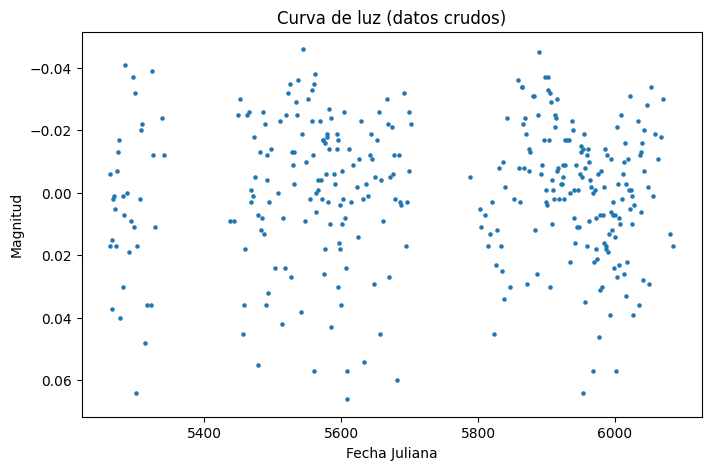

In [99]:
# gráfico crudo
plt.figure(figsize=(8,5))
plt.scatter(t, mag, s=5)
plt.gca().invert_yaxis()  # importante para magnitudes
plt.xlabel("Fecha Juliana")
plt.ylabel("Magnitud")
plt.title("Curva de luz (datos crudos)")
plt.show()

In [100]:
# rango de periodos deseado
P_min = 0.1     # días (ajústalo si quieres)
P_max = 20     # días

# convertir a frecuencias
f_max = 1 / P_min
f_min = 1 / P_max

frequency, power = LombScargle(t, flux).autopower(
    minimum_frequency=f_min,
    maximum_frequency=f_max
)

# convertir a periodo
period = 1 / frequency

In [101]:
best_period = period[np.argmax(power)]
print("Periodo dominante:", best_period, "días")

Periodo dominante: 1.5467483951191308 días


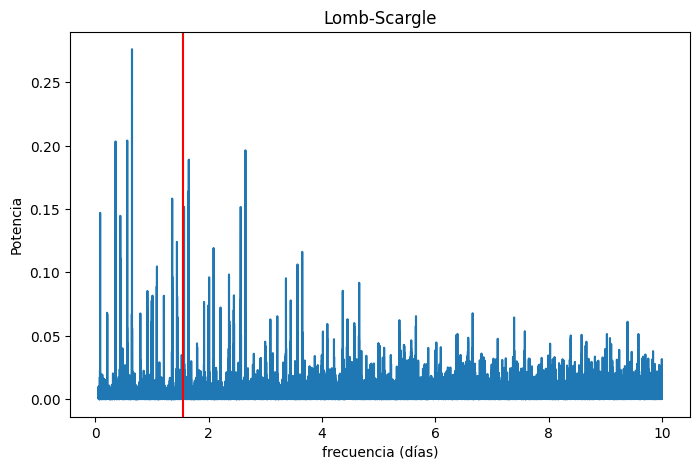

In [102]:
plt.figure(figsize=(8,5))
plt.plot(frequency, power)
plt.xlabel("frecuencia (días)")
plt.ylabel("Potencia")
plt.axvline(1.547, color = "red")
plt.title("Lomb-Scargle")
plt.show()

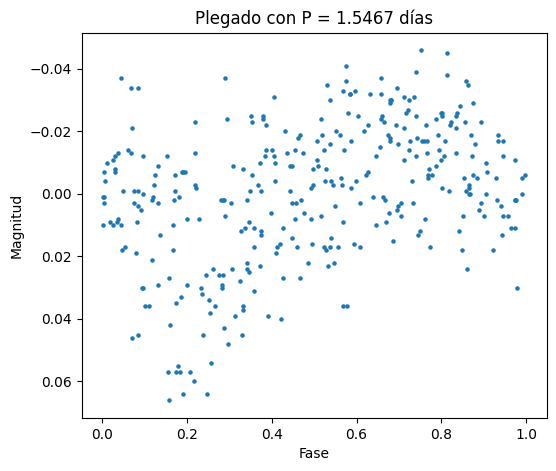

In [103]:
phase = (t % best_period) / best_period

plt.figure(figsize=(6,5))
plt.scatter(phase, mag, s=5)
plt.gca().invert_yaxis()  # magnitudes
plt.xlabel("Fase")
plt.ylabel("Magnitud")
plt.title(f"Plegado con P = {best_period:.4f} días")
plt.show()

In [104]:
max_modes = 10
threshold_fap = 0.01

residuals = flux.copy()
detected_periods = []

for i in range(max_modes):

    ls = LombScargle(t, residuals)
    frequency, power = ls.autopower(
        minimum_frequency=f_min,
        maximum_frequency=f_max
    )

    idx = np.argmax(power)
    best_freq = frequency[idx]
    
    fap = ls.false_alarm_probability(power[idx])
    
    print(f"\nIteración {i+1}")
    print(f"FAP: {fap}")

    if fap > threshold_fap:
        print("No hay más señales significativas.")
        break

    best_period = 1 / best_freq
    detected_periods.append(best_period)

    # ajuste seno
    model = models.Sine1D(
        amplitude=np.std(residuals),
        frequency=best_freq
    )

    fitter = fitting.LevMarLSQFitter()
    fit = fitter(model, t, residuals)

    residuals = residuals - fit(t)

    print(f"Periodo detectado: {best_period:.5f} d")


Iteración 1
FAP: 7.628200567622358e-21
Periodo detectado: 1.54675 d

Iteración 2
FAP: 1.0009486099379749e-19
Periodo detectado: 1.77773 d

Iteración 3
FAP: 5.496850488322624e-13
Periodo detectado: 0.49794 d

Iteración 4
FAP: 3.299592203201469e-14
Periodo detectado: 11.87192 d

Iteración 5
FAP: 2.3059094637023597e-13
Periodo detectado: 0.82710 d

Iteración 6
FAP: 3.127844333807114e-05
Periodo detectado: 0.50078 d

Iteración 7
FAP: 0.0014682198428323462
Periodo detectado: 2.08875 d

Iteración 8
FAP: 0.0037289803109153427
Periodo detectado: 0.85615 d

Iteración 9
FAP: 0.04507739270269
No hay más señales significativas.


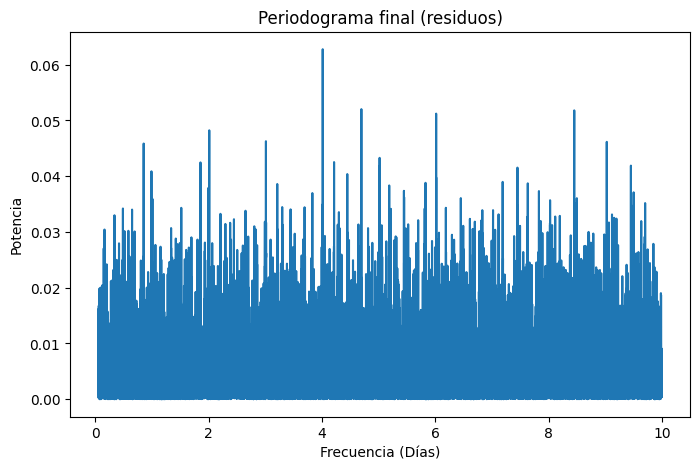

In [105]:
# =========================
# 6. Gráfico del último periodograma
# =========================
frequency, power = LombScargle(t, residuals).autopower(
    minimum_frequency=f_min,
    maximum_frequency=f_max
)

plt.figure(figsize=(8,5))
plt.plot(frequency, power)
plt.xlabel("Frecuencia (Días)")
plt.ylabel("Potencia")
plt.title("Periodograma final (residuos)")
plt.show()

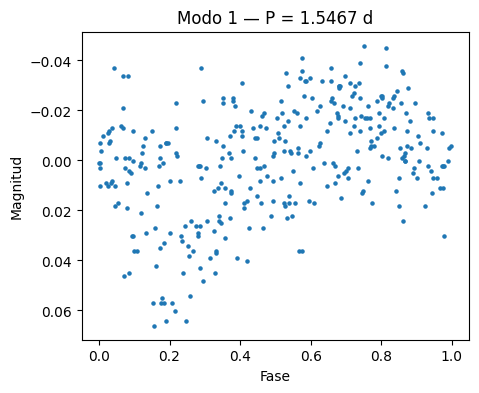

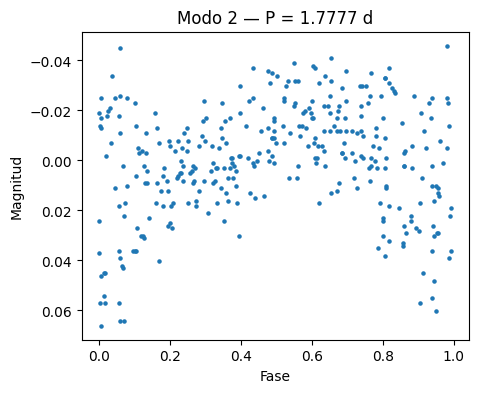

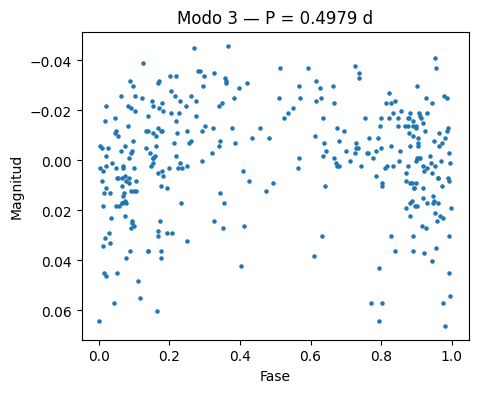

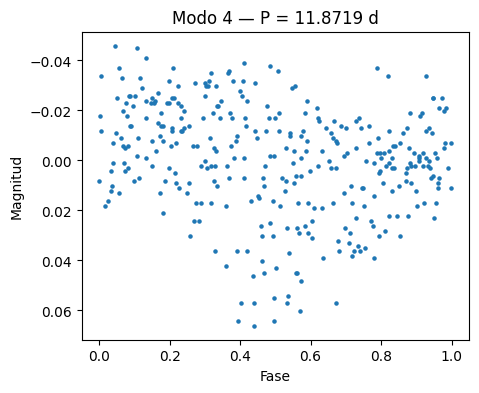

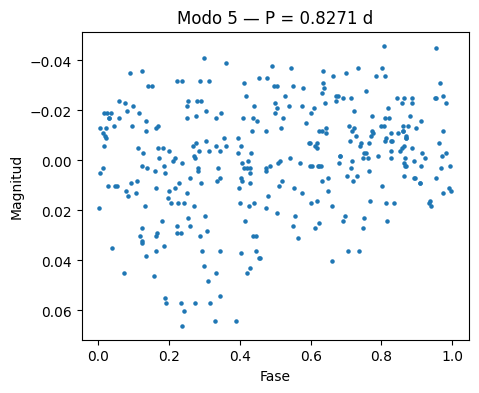

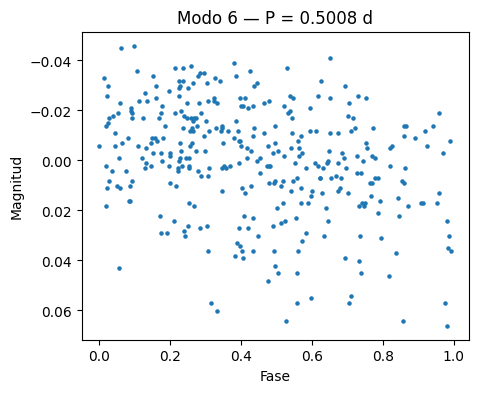

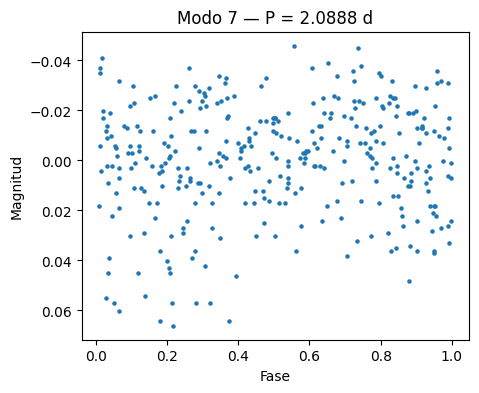

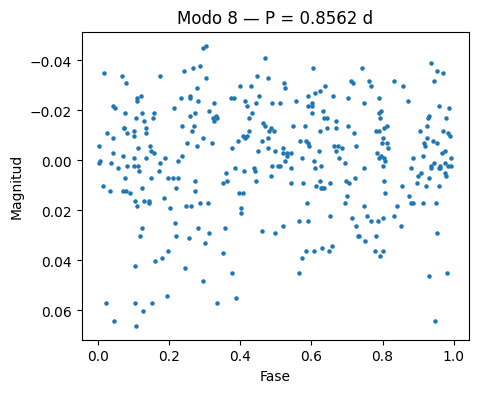

In [106]:
# =========================
# 7. Plegado de cada modo
# =========================
for i, P in enumerate(detected_periods):
    phase = (t % P) / P
    
    plt.figure(figsize=(5,4))
    plt.scatter(phase, mag, s=5)
    plt.gca().invert_yaxis()
    plt.xlabel("Fase")
    plt.ylabel("Magnitud")
    plt.title(f"Modo {i+1} — P = {P:.4f} d")
    plt.show()

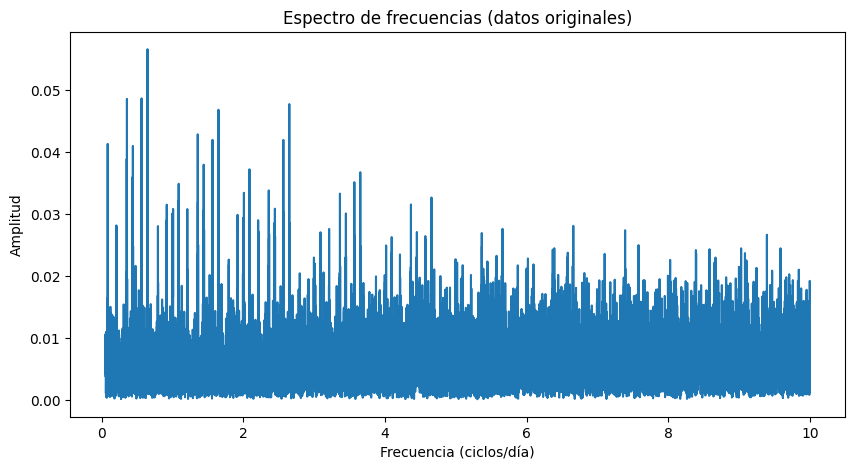

In [107]:
ls = LombScargle(t, flux)

frequency, power = ls.autopower(
    minimum_frequency=f_min,
    maximum_frequency=f_max
)

# convertir a algo más interpretable (amplitud tipo paper)
amplitude = np.sqrt(4 * power / len(t))

plt.figure(figsize=(10,5))
plt.plot(frequency, amplitude)
plt.xlabel("Frecuencia (ciclos/día)")
plt.ylabel("Amplitud")
plt.title("Espectro de frecuencias (datos originales)")
plt.show()

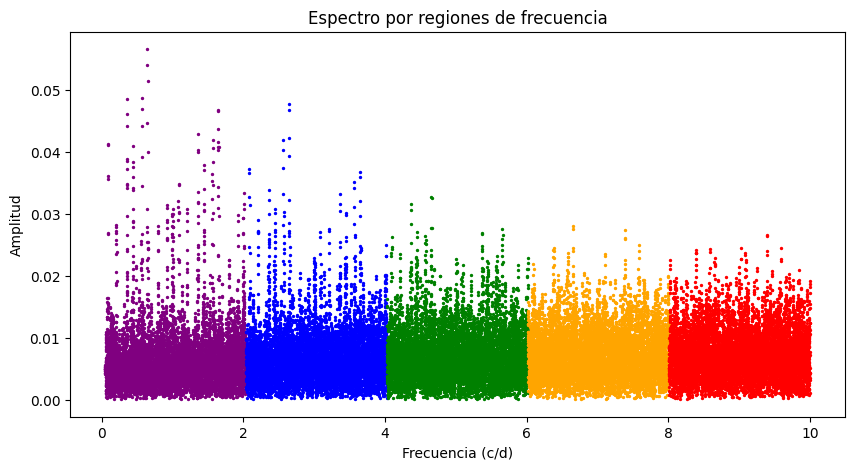

In [108]:
plt.figure(figsize=(10,5))

# dividir en bandas (ejemplo visual)
colors = ['purple','blue','green','orange','red']

bins = np.linspace(f_min, f_max, len(colors)+1)

for i in range(len(colors)):
    mask = (frequency >= bins[i]) & (frequency < bins[i+1])
    plt.scatter(frequency[mask], amplitude[mask], s=2, color=colors[i])

plt.xlabel("Frecuencia (c/d)")
plt.ylabel("Amplitud")
plt.title("Espectro por regiones de frecuencia")
plt.show()